<a href="https://colab.research.google.com/github/ArthBachhuka123/MachineLearning/blob/main/PyTorch2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kaggle
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d zalando-research/fashionmnist

Dataset URL: https://www.kaggle.com/datasets/zalando-research/fashionmnist
License(s): other
 95% 65.0M/68.8M [00:00<00:00, 328MB/s]
100% 68.8M/68.8M [00:00<00:00, 320MB/s]


In [6]:
import zipfile
import os
zip_path = "/content/fashionmnist.zip"
extract_to = "/content"

with zipfile.ZipFile(zip_path,"r") as zip_ref:
  zip_ref.extractall(extract_to)

In [7]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split

In [8]:
torch.manual_seed(41)

In [9]:
data = pd.read_csv("/content/fashion-mnist_train.csv")

In [10]:
test_data = pd.read_csv("/content/fashion-mnist_test.csv")

In [11]:
test_data.shape

(10000, 785)

In [12]:
data.shape

(60000, 785)

In [13]:
X = data.drop("label",axis=1)
y = data["label"]

In [14]:
X_train,X_val,y_train,y_val = train_test_split(X,y,test_size=0.2,random_state=42)

In [15]:
X_train = X_train/255
X_val = X_val/255

Label:  6


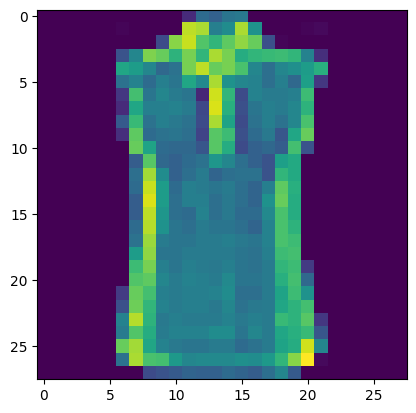

In [16]:
import matplotlib.pyplot as plt
plt.imshow(X_train.iloc[6].values.reshape(28,28))
print("Label: ",y_train.iloc[6])

Label:  2


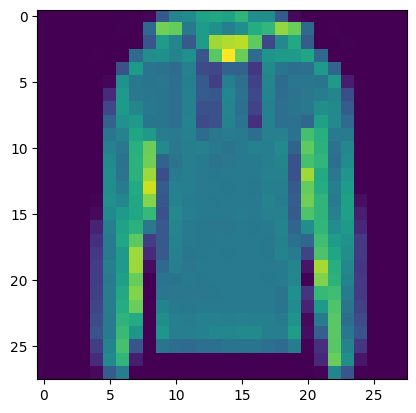

In [17]:
plt.imshow(X_val.iloc[6].values.reshape(28,28))
print("Label: ",y_val.iloc[6])

In [18]:
from torch.utils.data import DataLoader , Dataset
class CustomDataset(Dataset):
  def __init__(self,features,labels):
    self.features = torch.tensor(features.values,dtype=torch.float32)
    self.labels = torch.tensor(labels.values,dtype=torch.long)
  def __len__(self):
    return len(self.features)
  def __getitem__(self,idx):
    return self.features[idx],self.labels[idx]


In [19]:
train_dataset = CustomDataset(X_train,y_train)
val_dataset = CustomDataset(X_val,y_val)
test_dataset = CustomDataset(test_data.drop("label",axis=1),test_data["label"])

In [20]:
train_dataset.features.shape

torch.Size([48000, 784])

In [21]:
test_dataset.features.shape

torch.Size([10000, 784])

In [22]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True,pin_memory=True)
val_loader = DataLoader(val_dataset,batch_size=32,shuffle=False,pin_memory=True)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False,pin_memory=True)

In [23]:
len(train_loader)

1500

In [24]:
len(val_loader)

375

In [25]:
len(test_loader)

313

In [26]:
import torch.nn as nn
class Model(nn.Module):
  def __init__(self,num_features):
    super().__init__()
    self.network = nn.Sequential(
        nn.Linear(num_features,128),
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(128,64),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(64,10)
    )
  def forward(self,features):
    return self.network(features)


In [27]:
torch.cuda.is_available()

True

In [28]:
!pip install torchinfo

In [29]:
from torchinfo import summary
model = Model(X_train.shape[1])
model = model.to("cuda")
summary(model, input_size=(32, X_train.shape[1]))  # batch_size, num_features


Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [32, 10]                  --
├─Sequential: 1-1                        [32, 10]                  --
│    └─Linear: 2-1                       [32, 128]                 100,480
│    └─BatchNorm1d: 2-2                  [32, 128]                 256
│    └─ReLU: 2-3                         [32, 128]                 --
│    └─Dropout: 2-4                      [32, 128]                 --
│    └─Linear: 2-5                       [32, 64]                  8,256
│    └─BatchNorm1d: 2-6                  [32, 64]                  128
│    └─ReLU: 2-7                         [32, 64]                  --
│    └─Dropout: 2-8                      [32, 64]                  --
│    └─Linear: 2-9                       [32, 10]                  650
Total params: 109,770
Trainable params: 109,770
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 3.51
Input size (MB): 0.10
Forward/ba

In [30]:
epochs = 100
lr = 0.1

In [31]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=1e-4)
model.train()
for epoch in range(1, epochs + 1):
    total_epoch_loss = 0
    for batch_features, batch_labels in train_loader:
        batch_features = batch_features.to("cuda")
        batch_labels = batch_labels.to("cuda")
        outputs = model(batch_features)
        loss = criterion(outputs, batch_labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_epoch_loss += loss.item()
    avg_loss = total_epoch_loss / len(train_loader)
    print(f"Epoch: {epoch}  Loss: {avg_loss:.4f}")



Epoch: 1  Loss: 0.5846
Epoch: 2  Loss: 0.4585
Epoch: 3  Loss: 0.4213
Epoch: 4  Loss: 0.3971
Epoch: 5  Loss: 0.3836
Epoch: 6  Loss: 0.3681
Epoch: 7  Loss: 0.3521
Epoch: 8  Loss: 0.3457
Epoch: 9  Loss: 0.3348
Epoch: 10  Loss: 0.3316
Epoch: 11  Loss: 0.3227
Epoch: 12  Loss: 0.3184
Epoch: 13  Loss: 0.3126
Epoch: 14  Loss: 0.3088
Epoch: 15  Loss: 0.3017
Epoch: 16  Loss: 0.3001
Epoch: 17  Loss: 0.2931
Epoch: 18  Loss: 0.2908
Epoch: 19  Loss: 0.2866
Epoch: 20  Loss: 0.2866
Epoch: 21  Loss: 0.2813
Epoch: 22  Loss: 0.2776
Epoch: 23  Loss: 0.2772
Epoch: 24  Loss: 0.2730
Epoch: 25  Loss: 0.2717
Epoch: 26  Loss: 0.2684
Epoch: 27  Loss: 0.2649
Epoch: 28  Loss: 0.2664
Epoch: 29  Loss: 0.2634
Epoch: 30  Loss: 0.2652
Epoch: 31  Loss: 0.2601
Epoch: 32  Loss: 0.2576
Epoch: 33  Loss: 0.2545
Epoch: 34  Loss: 0.2542
Epoch: 35  Loss: 0.2539
Epoch: 36  Loss: 0.2502
Epoch: 37  Loss: 0.2522
Epoch: 38  Loss: 0.2475
Epoch: 39  Loss: 0.2474
Epoch: 40  Loss: 0.2486
Epoch: 41  Loss: 0.2409
Epoch: 42  Loss: 0.2439
E

In [32]:
model.eval()
accuracy_list = []
with torch.no_grad():
  for batch_features,batch_labels in val_loader:
    batch_features = batch_features.to("cuda")
    batch_labels = batch_labels.to("cuda")
    output = model(batch_features)
    prediction = torch.argmax(output,dim=1)
    accuracy_list.append((prediction==batch_labels).float().mean())
  overall_accuracy = sum(accuracy_list)/len(accuracy_list)
  print(f"val accuracy: {overall_accuracy}")


val accuracy: 0.8912500143051147


In [33]:
model.eval()
test_accuracy=[]
with torch.no_grad():
  for batch_features,batch_labels in test_loader:
    batch_features=batch_features.to("cuda")
    batch_labels=batch_labels.to("cuda")
    output = model(batch_features)
    prediction = torch.argmax(output,dim=1)
    test_accuracy.append((prediction==batch_labels).float().mean())
  overall_accuracy = sum(test_accuracy)/len(test_accuracy)
  print(f"test accuracy: {overall_accuracy}")

test accuracy: 0.8399560451507568
